<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project23_Reinforcement_Learning_Proximal_Policy_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install stable-baselines3[extra]
!pip install gymnasium
!pip install shimmy
!pip install ccxt



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.3/143.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 19.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO

import ccxt




Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [3]:
exchange = ccxt.kucoin()


bars = exchange.fetch_ohlcv(
    'BTC/USDT',
    timeframe='1h',
    limit=1000
)



df = pd.DataFrame(
    bars,
    columns=['timestamp',  'open',  'high',  'low',  'close',  'volume']
)


df['timestamp']  = pd.to_datetime(df['timestamp'],  unit='ms')


df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,timestamp,open,high,low,close,volume
0,2026-04-03 00:00:00,66906.8,67000.9,66709.8,66790.3,40.496936
1,2026-04-03 01:00:00,66790.3,66902.3,66493.6,66625.5,65.022404
2,2026-04-03 02:00:00,66628.4,66748.9,66279.1,66531.0,78.517043
3,2026-04-03 03:00:00,66535.6,66724.5,66500.1,66592.6,42.140746
4,2026-04-03 04:00:00,66589.5,66697.3,66513.3,66611.5,43.428485


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


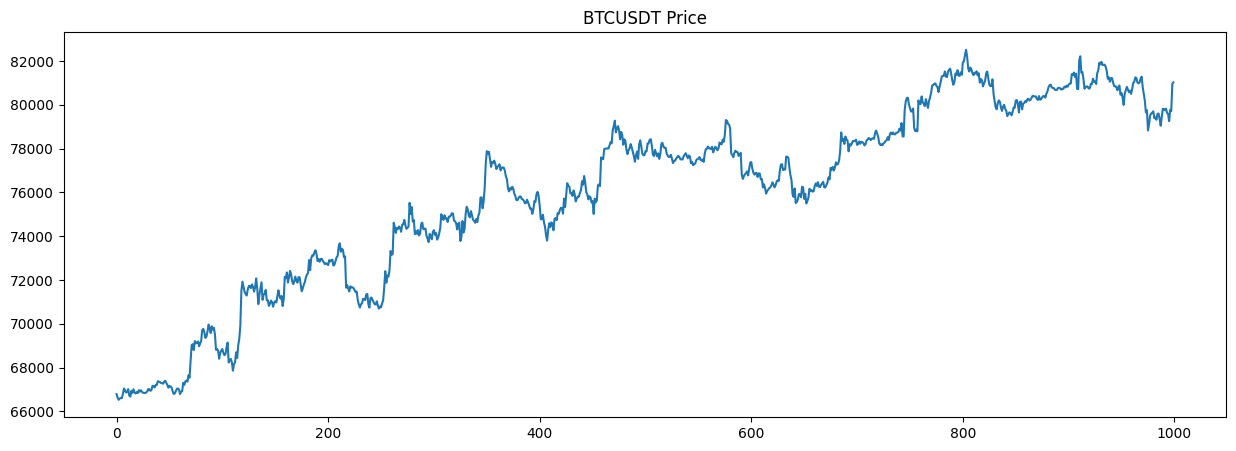

In [4]:
plt.figure(figsize=(15,5))

plt.plot(df['close'])

plt.title('BTCUSDT Price')
plt.show()



In [5]:
df['ema20'] = df['close'].ewm(span=20).mean()
df['ema50'] = df['close'].ewm(span=50).mean()



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
delta = df['close'].diff()


gain = (delta.where( delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0 , 0)).rolling(14).mean()


rs = gain/loss


df['rsi'] = 100 - (100 / (1+rs)   )

df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,timestamp,open,high,low,close,volume,ema20,ema50,rsi
0,2026-04-03 00:00:00,66906.8,67000.9,66709.8,66790.3,40.496936,66790.300000,66790.300000,NaN
1,2026-04-03 01:00:00,66790.3,66902.3,66493.6,66625.5,65.022404,66703.780000,66706.252000,NaN
2,2026-04-03 02:00:00,66628.4,66748.9,66279.1,66531.0,78.517043,66640.336220,66645.482709,NaN
3,2026-04-03 03:00:00,66535.6,66724.5,66500.1,66592.6,42.140746,66626.555511,66631.458430,NaN
4,2026-04-03 04:00:00,66589.5,66697.3,66513.3,66611.5,43.428485,66622.913711,66627.141155,NaN
...,...,...,...,...,...,...,...,...,...
995,2026-05-14 11:00:00,79579.2,79611.8,79232.2,79256.1,38.573413,79672.865395,80077.119915,47.239786
996,2026-05-14 12:00:00,79250.4,79788.4,79234.7,79776.0,41.649292,79682.687738,80065.311291,55.880559
997,2026-05-14 13:00:00,79775.9,80059.9,79675.1,79719.4,87.087266,79686.184144,80051.746142,56.892922
998,2026-05-14 14:00:00,79679.7,81014.9,79555.4,80967.1,137.601630,79808.176130,80087.642372,67.766740


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

df

,timestamp,open,high,low,close,volume,ema20,ema50,rsi
0,2026-04-03 13:00:00,66722.7,66735.5,66512.2,66676.0,38.225257,66792.758342,66778.565520,46.113567
1,2026-04-03 14:00:00,66676.1,66997.0,66635.5,66943.4,48.133652,66811.219184,66792.890952,54.404741
2,2026-04-03 15:00:00,66939.3,67030.3,66824.1,66849.0,44.139734,66815.726066,66797.545300,56.701649
3,2026-04-03 16:00:00,66842.8,67070.9,66832.1,67011.8,31.010279,66838.566414,66814.573375,63.849522
4,2026-04-03 17:00:00,67010.2,67067.2,66758.8,66851.5,29.744464,66840.041677,66817.394568,57.056419
...,...,...,...,...,...,...,...,...,...
982,2026-05-14 11:00:00,79579.2,79611.8,79232.2,79256.1,38.573413,79672.865395,80077.119915,47.239786
983,2026-05-14 12:00:00,79250.4,79788.4,79234.7,79776.0,41.649292,79682.687738,80065.311291,55.880559
984,2026-05-14 13:00:00,79775.9,80059.9,79675.1,79719.4,87.087266,79686.184144,80051.746142,56.892922
985,2026-05-14 14:00:00,79679.7,81014.9,79555.4,80967.1,137.601630,79808.176130,80087.642372,67.766740


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**now lets write the classfile which can do the reiforcement learning**

In [18]:
class TradingEnv(gym.Env):


  def __init__(self, df):

    super(TradingEnv, self).__init__()


    self.df = df

    self.current_step = 0

    self.trades  = []

    self.balance = 1000
    self.position = 0
    self.net_worth = 1000



    # 0 is hold, 1 is buy, 2 is sell

    self.action_space = spaces.Discrete(3)


    self.observation_space = spaces.Box(
        low = -np.inf,
        high = np.inf,
        shape = (5,)  ,
        dtype= np.float32

    )



  def _get_observation(self):

    row = self.df.iloc[self.current_step]


    obs = np.array([

                    row['close'],
                    row['ema20'],
                    row['ema50'],
                    row['rsi'],
                    self.position
    ],   dtype= np.float32
                   )


    return obs



  def reset(self, seed=None, options=None):

    super().reset(seed=seed)


    self.current_step = 0

    self.balance = 1000
    self.position = 0
    self.net_worth = 1000
    self.net_worths = []


    return self._get_observation(),   {}




  def step(self, action):
    price = self.df.iloc[self.current_step]['close']

    old_net_worth = self.net_worth


    #now we write buy section
    if action == 1 and self.position == 0:
      self.position = 1
      self.entry_price = price


    #now sell section
    elif action == 2 and self.position == 1:
      profit = price - self.entry_price
      self.balance += profit
      self.position = 0
      self.trades.append(profit)


    #now we update net worth
    self.net_worth = self.balance

    self.net_worths.append(self.net_worth)


    #the main thing. the reward. we have to define it carefully
    reward  = self.net_worth - old_net_worth

    self.current_step += 1

    terminated = self.current_step >= len(self.df) - 1

    truncated = False


    return (

            self._get_observation(),
            reward,
            terminated,
            truncated,
            {}

    )


**ini model in run cheyyaan ulla simulated environment define cheyaam**

In [19]:
env = TradingEnv(df)



In [20]:
model = PPO(
    "MlpPolicy",
    env,
    verbose = 1
)



model.learn(total_timesteps=10_000)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 986      |
|    ep_rew_mean     | 4.46e+03 |
| time/              |          |
|    fps             | 1244     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 986         |
|    ep_rew_mean          | 5.64e+03    |
| time/                   |             |
|    fps                  | 958         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009318268 |
|    clip_fraction        | 0.00313     |
|    clip_range           | 0.2         |
|    entropy_loss   

**looks good, test cheyth nokaam**

In [21]:
obs, _ = env.reset()

done = False




while not done:

  action, _states = model.predict(obs)
  obs,reward,terminated , truncated, info = env.step(action)


  done = terminated or truncated



print("Final balance: ", env.balance)




Final balance:  14749.100000000035


**ambo !!**

In [22]:
print(env.trades)

[np.float64(267.3999999999942), np.float64(-47.89999999999418), np.float64(174.89999999999418), np.float64(187.10000000000582), np.float64(133.09999999999127), np.float64(6.19999999999709), np.float64(-286.90000000000873), np.float64(121.09999999999127), np.float64(128.90000000000873), np.float64(-95.60000000000582), np.float64(170.90000000000873), np.float64(44.30000000000291), np.float64(504.5), np.float64(607.5), np.float64(-212.59999999999127), np.float64(-378.1999999999971), np.float64(-195.39999999999418), np.float64(-703.5), np.float64(-157.5), np.float64(369.59999999999127), np.float64(-221.89999999999418), np.float64(-177.0), np.float64(163.6999999999971), np.float64(-91.39999999999418), np.float64(386.8999999999942), np.float64(410.0), np.float64(-797.6000000000058), np.float64(-382.8999999999942), np.float64(-176.1999999999971), np.float64(3.400000000008731), np.float64(-65.89999999999418), np.float64(175.60000000000582), np.float64(-91.30000000000291), np.float64(-129.89999

**lets plot it**

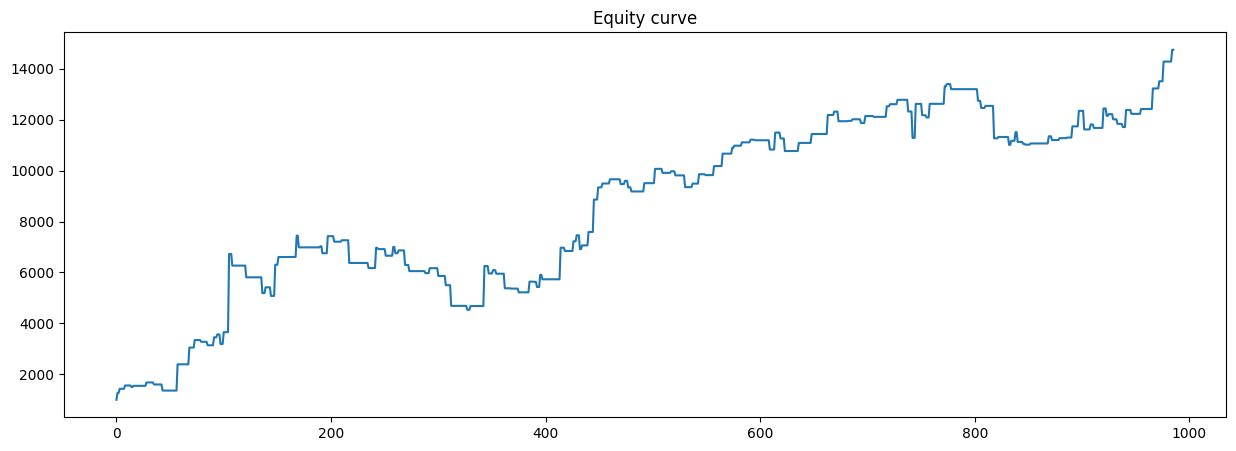

In [23]:
plt.figure(figsize=(15,5))
plt.plot(env.net_worths)
plt.title('Equity curve')
plt.show()

**curve okke kanaan kollaam... dhaivam thamburaan ariyaam ithokke real money vach run cheyth nokkia profit varo loss varo nnu!!**


**aa hell ennenkilum oru divasam gunam cheyumaairikkum !**